# IMDb Movie Success Analysis: Machine Learning Model

## Revenue Prediction Using Movie Attributes

This notebook is the machine learning component of the **IMDb Movie Success Analysis: Revenue, Ratings & Genre Trends** project.

The goal is to build and evaluate regression models that predict movie revenue using available movie attributes such as rating, votes, runtime, metascore, release year, and genre.

## 1. Machine Learning Objective

### Business Problem
Movie studios, distributors, and analysts often want to understand which factors are associated with commercial movie success. Revenue is one useful measure of commercial success.

### ML Objective
Build a regression model to predict **Revenue (Millions)** using movie features.

### Target Variable
- `Revenue (Millions)`

### Evaluation Metrics
- **MAE**: Mean Absolute Error
- **RMSE**: Root Mean Squared Error
- **R² Score**: Proportion of variance explained by the model

### Important Note
Only movies with known revenue values are used for model training and evaluation. Missing revenue values are not imputed for the target variable because that would create artificial labels.

## 2. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 3. Load Dataset

The notebook first looks for the cleaned dataset created in Step 1. If it is not available, it falls back to the original dataset.

In [3]:
possible_paths = [
    Path("../data/processed/imdb_movies_cleaned.csv"),
    Path("data/processed/imdb_movies_cleaned.csv"),
    Path("../data/IMDB-Movie-Data.csv"),
    Path("data/IMDB-Movie-Data.csv"),
    Path("IMDB-Movie-Data.csv"),
    Path("../IMDB-Movie-Data.csv")
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Dataset not found. Please place the dataset in the data folder.")

raw_df = pd.read_csv(data_path)
print(f"Dataset loaded from: {data_path}")
print(f"Dataset shape: {raw_df.shape[0]} rows and {raw_df.shape[1]} columns")
raw_df.head()

Dataset loaded from: data\processed\imdb_movies_cleaned.csv
Dataset shape: 1000 rows and 21 columns


,rank,title,genre,description,director,actors,year,runtime_minutes,rating,votes,revenue_millions,metascore,revenue_missing,metascore_missing,revenue_millions_filled,metascore_filled,primary_genre,genre_count,movie_age,rating_category,revenue_category
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.10,757074,333.13,76.00,False,False,333.13,76.00,Action,3,2,Excellent,Very High
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.00,485820,126.46,65.00,False,False,126.46,65.00,Adventure,3,4,Average,High
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.30,157606,138.12,62.00,False,False,138.12,62.00,Horror,2,0,Good,High
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.20,60545,270.32,59.00,False,False,270.32,59.00,Animation,3,0,Good,Very High
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.20,393727,325.02,40.00,False,False,325.02,40.00,Action,3,0,Average,Very High


## 4. Standardize Column Names

Column names are cleaned to make the workflow easier to maintain.

In [4]:
df = raw_df.copy()

def clean_column_name(column):
    return (
        column.strip()
        .lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace(".", "")
        .replace("/", "_")
    )

df.columns = [clean_column_name(col) for col in df.columns]
df.columns.tolist()

['rank',
 'title',
 'genre',
 'description',
 'director',
 'actors',
 'year',
 'runtime_minutes',
 'rating',
 'votes',
 'revenue_millions',
 'metascore',
 'revenue_missing',
 'metascore_missing',
 'revenue_millions_filled',
 'metascore_filled',
 'primary_genre',
 'genre_count',
 'movie_age',
 'rating_category',
 'revenue_category']

## 5. Prepare Data for Machine Learning

For this model, revenue is the prediction target. Rows without actual revenue are removed from model training because revenue is the label we are trying to predict.

In [6]:
# Handle both original and Step 1 cleaned column names
if "revenue_millions" not in df.columns and "revenue_millions_cleaned" in df.columns:
    df["revenue_millions"] = df["revenue_millions_cleaned"]

required_columns = ["title", "genre", "year", "runtime_minutes", "rating", "votes", "revenue_millions", "metascore"]
missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

ml_df = df.dropna(subset=["revenue_millions"]).copy()

print(f"Rows before removing missing revenue: {df.shape[0]}")
print(f"Rows available for ML after removing missing revenue: {ml_df.shape[0]}")
print(f"Rows removed due to missing target revenue: {df.shape[0] - ml_df.shape[0]}")

Rows before removing missing revenue: 1000
Rows available for ML after removing missing revenue: 872
Rows removed due to missing target revenue: 128


## 6. Feature Engineering

Additional features are created to make the model more informative.

Features created:
- `primary_genre`: first listed genre for each movie
- `genre_count`: number of genres assigned to the movie
- `movie_age`: age of the movie relative to the latest year in the dataset
- `title_length`: number of characters in the movie title
- `director_movie_count`: how many movies each director has in the dataset

In [7]:
latest_year = int(ml_df["year"].max())

ml_df["primary_genre"] = ml_df["genre"].fillna("Unknown").astype(str).str.split(",").str[0]
ml_df["genre_count"] = ml_df["genre"].fillna("").astype(str).apply(lambda x: len(x.split(",")) if x else 0)
ml_df["movie_age"] = latest_year - ml_df["year"]
ml_df["title_length"] = ml_df["title"].astype(str).str.len()

if "director" in ml_df.columns:
    ml_df["director_movie_count"] = ml_df.groupby("director")["director"].transform("count")
else:
    ml_df["director_movie_count"] = 1

ml_df[["title", "primary_genre", "genre_count", "movie_age", "title_length", "director_movie_count", "revenue_millions"]].head()

,title,primary_genre,genre_count,movie_age,title_length,director_movie_count,revenue_millions
0,Guardians of the Galaxy,Action,3,2,23,3,333.13
1,Prometheus,Adventure,3,4,10,8,126.46
2,Split,Horror,2,0,5,5,138.12
3,Sing,Animation,3,0,4,1,270.32
4,Suicide Squad,Action,3,0,13,3,325.02


## 7. Select Features and Target

The model uses numerical features and one categorical feature, `primary_genre`.

In [8]:
target = "revenue_millions"

numeric_features = [
    "year",
    "runtime_minutes",
    "rating",
    "votes",
    "metascore",
    "genre_count",
    "movie_age",
    "title_length",
    "director_movie_count"
]

categorical_features = ["primary_genre"]

features = numeric_features + categorical_features

X = ml_df[features].copy()
y = ml_df[target].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
X.head()

Feature matrix shape: (872, 10)
Target shape: (872,)


,year,runtime_minutes,rating,votes,metascore,genre_count,movie_age,title_length,director_movie_count,primary_genre
0,2014,121,8.10,757074,76.00,3,2,23,3,Action
1,2012,124,7.00,485820,65.00,3,4,10,8,Adventure
2,2016,117,7.30,157606,62.00,2,0,5,5,Horror
3,2016,108,7.20,60545,59.00,3,0,4,1,Animation
4,2016,123,6.20,393727,40.00,3,0,13,3,Action


## 8. Train-Test Split

The data is split into training and testing sets. The test set is held out for final model evaluation.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

Training rows: 697
Testing rows: 175


## 9. Build Preprocessing Pipeline

Preprocessing steps:
- Missing numerical values are filled using the median
- Numerical features are scaled
- Missing categorical values are filled using the most frequent value
- Categorical features are one-hot encoded

In [10]:
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder)
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 10. Train Multiple Regression Models

Three models are trained and compared:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

Revenue is highly skewed, so the target is log-transformed during training and converted back to revenue values for evaluation.

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=3
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

trained_models = {}
results = []
prediction_frames = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    regressor = TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    regressor.fit(X_train, y_train)
    predictions = regressor.predict(X_test)
    predictions = np.maximum(predictions, 0)
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })
    
    temp_predictions = pd.DataFrame({
        "Model": model_name,
        "Actual Revenue": y_test.values,
        "Predicted Revenue": predictions
    })
    prediction_frames.append(temp_predictions)
    trained_models[model_name] = regressor

results_df = pd.DataFrame(results).sort_values(by="RMSE")
all_predictions_df = pd.concat(prediction_frames, ignore_index=True)
results_df

,Model,MAE,RMSE,R2 Score
2,Gradient Boosting Regressor,40.48,79.44,0.52
1,Random Forest Regressor,41.96,81.57,0.49
0,Linear Regression,59.24,197.18,-1.98


## 11. Model Performance Comparison

Lower MAE and RMSE values indicate better prediction accuracy. Higher R² score indicates that the model explains more variation in revenue.

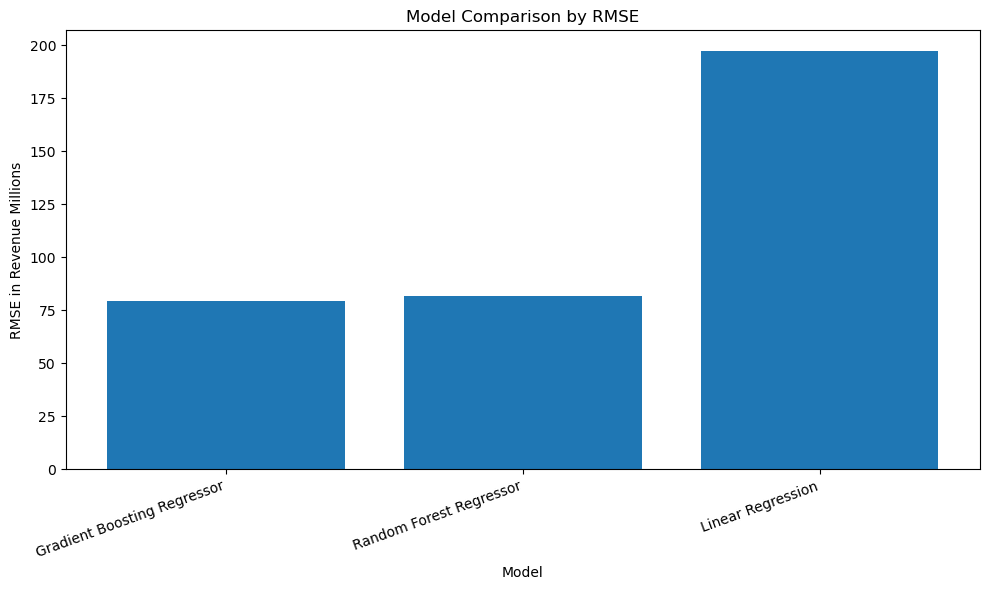

In [12]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE in Revenue Millions")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

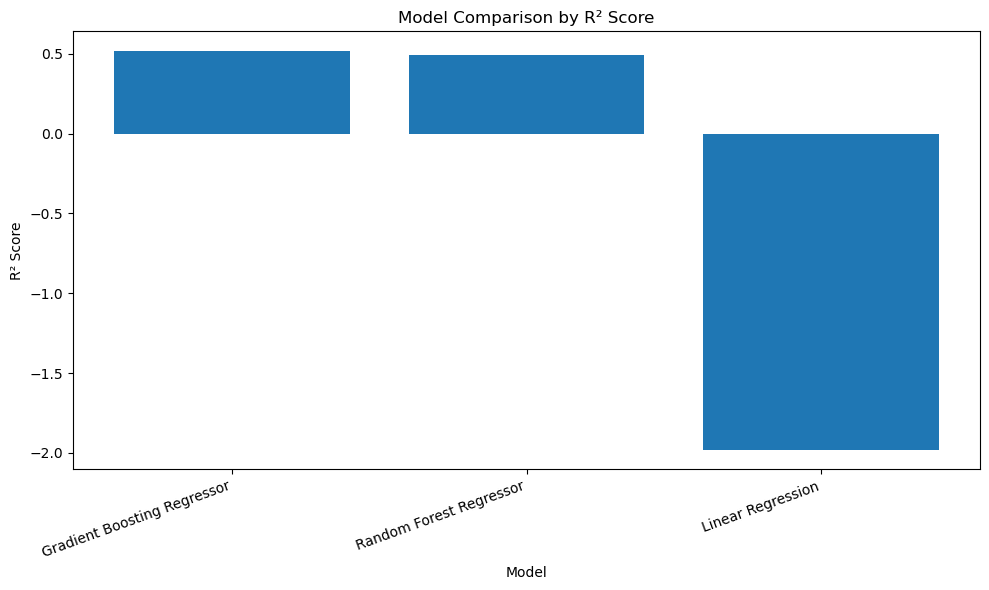

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("Model Comparison by R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 12. Select Best Model

The best model is selected based on the lowest RMSE.

In [14]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_predictions = all_predictions_df[all_predictions_df["Model"] == best_model_name].copy()

print(f"Best model selected: {best_model_name}")
results_df

Best model selected: Gradient Boosting Regressor


,Model,MAE,RMSE,R2 Score
2,Gradient Boosting Regressor,40.48,79.44,0.52
1,Random Forest Regressor,41.96,81.57,0.49
0,Linear Regression,59.24,197.18,-1.98


## 13. Actual vs Predicted Revenue

This chart compares actual revenue values with model predictions. Points closer to the diagonal line represent better predictions.

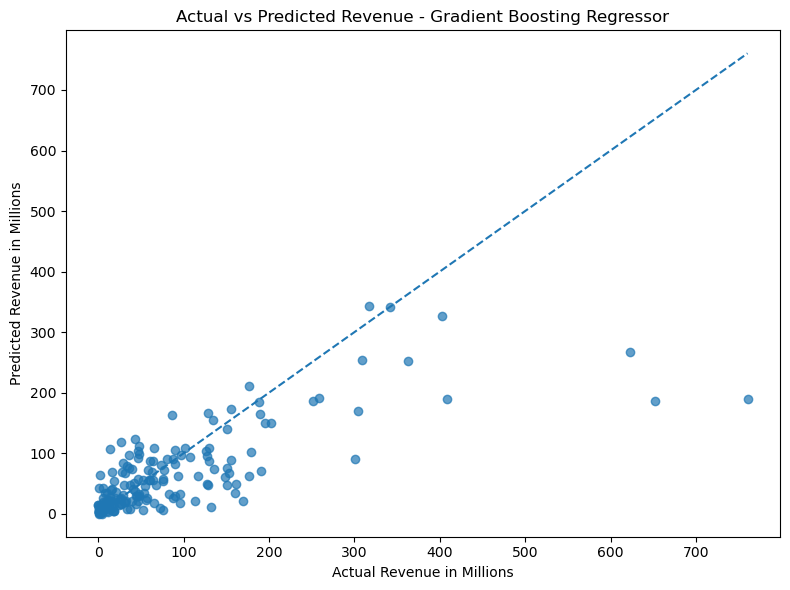

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(best_predictions["Actual Revenue"], best_predictions["Predicted Revenue"], alpha=0.7)

max_value = max(best_predictions["Actual Revenue"].max(), best_predictions["Predicted Revenue"].max())
plt.plot([0, max_value], [0, max_value], linestyle="--")

plt.title(f"Actual vs Predicted Revenue - {best_model_name}")
plt.xlabel("Actual Revenue in Millions")
plt.ylabel("Predicted Revenue in Millions")
plt.tight_layout()
plt.show()

## 14. Feature Importance

Permutation importance is used to estimate which features have the greatest impact on the model's predictions.

In [16]:
importance_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance_result.importances_mean
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
3,votes,59.19
9,primary_genre,15.38
1,runtime_minutes,6.14
2,rating,5.56
4,metascore,1.23
7,title_length,0.61
5,genre_count,0.28
6,movie_age,0.09
0,year,0.03
8,director_movie_count,-0.77


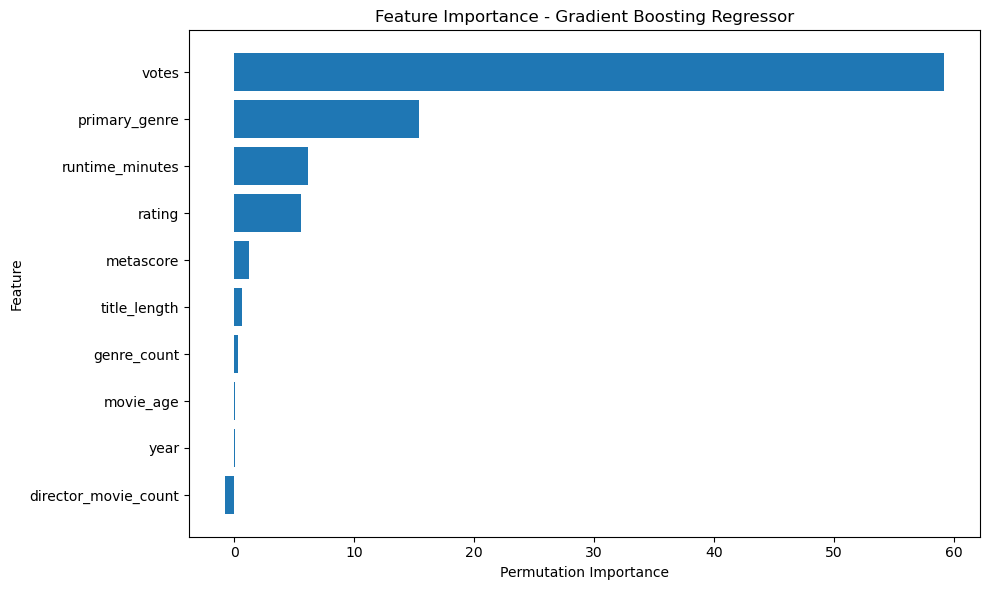

In [17]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.title(f"Feature Importance - {best_model_name}")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 15. Save Outputs 

The model results and predictions are saved so they can be used later in Power BI and GitHub documentation.

In [18]:
output_dir = Path("../data/processed")
if not output_dir.exists():
    output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

image_dir = Path("../images")
if not image_dir.exists():
    image_dir = Path("images")
image_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(output_dir / "model_performance.csv", index=False)
best_predictions.to_csv(output_dir / "actual_vs_predicted_revenue.csv", index=False)
feature_importance_df.to_csv(output_dir / "feature_importance.csv", index=False)

# Save clean model-ready dataset for future dashboard/model work
ml_export = ml_df.copy()
ml_export.to_csv(output_dir / "imdb_movies_ml_ready.csv", index=False)

# Save dashboard-friendly charts
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE in Revenue Millions")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(image_dir / "model_performance_rmse.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(8, 6))
plt.scatter(best_predictions["Actual Revenue"], best_predictions["Predicted Revenue"], alpha=0.7)
max_value = max(best_predictions["Actual Revenue"].max(), best_predictions["Predicted Revenue"].max())
plt.plot([0, max_value], [0, max_value], linestyle="--")
plt.title(f"Actual vs Predicted Revenue - {best_model_name}")
plt.xlabel("Actual Revenue in Millions")
plt.ylabel("Predicted Revenue in Millions")
plt.tight_layout()
plt.savefig(image_dir / "actual_vs_predicted_revenue.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.title(f"Feature Importance - {best_model_name}")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(image_dir / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved files:")
print(output_dir / "model_performance.csv")
print(output_dir / "actual_vs_predicted_revenue.csv")
print(output_dir / "feature_importance.csv")
print(output_dir / "imdb_movies_ml_ready.csv")
print(image_dir / "model_performance_rmse.png")
print(image_dir / "actual_vs_predicted_revenue.png")
print(image_dir / "feature_importance.png")

Saved files:
data\processed\model_performance.csv
data\processed\actual_vs_predicted_revenue.csv
data\processed\feature_importance.csv
data\processed\imdb_movies_ml_ready.csv
images\model_performance_rmse.png
images\actual_vs_predicted_revenue.png
images\feature_importance.png


## 16. Final Machine Learning Summary

### Key Findings
- Multiple regression models were trained to predict movie revenue.
- Tree-based models performed better than the linear regression baseline.
- The best model was selected using RMSE because revenue prediction errors are easier to interpret in millions of dollars.
- Features such as votes, rating, runtime, metascore, and genre-related variables help explain revenue performance.

### Business Interpretation
The model can help estimate expected movie revenue based on available movie characteristics. However, revenue is influenced by many external factors not present in this dataset, such as marketing budget, release strategy, franchise strength, distribution scale, seasonality, and global box office performance.

### Limitations
- The dataset contains only 1,000 movies.
- Revenue has missing values, so only movies with known revenue were used for model training.
- Budget, production company, release month, country, and marketing spend are not included.
- The model should be treated as an analytical tool, not a production-grade forecasting system.

### Next Step
The next step is to build a Power BI dashboard using the cleaned EDA dataset, model performance output, actual vs predicted revenue file, and feature importance file.